# Text Generation
The purpose of these models is to allow for general conversations outside agricultural ones to be conducted.

In [ ]:
!pip install evaluate sacrebleu bert-score jiwer mistral_common

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 63.6 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset
import torch

# Chatbot arena dataset
df = load_dataset("lmsys/chatbot_arena_conversations")

dataset_infos.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

data/train-00000-of-00001-5588d64a331985(…):   0%|          | 0.00/12.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44630 [00:00<?, ? examples/s]

In [ ]:
import evaluate

# Load the metrics
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")
wer_metric = evaluate.load("wer")
toxicity_metric = evaluate.load("toxicity", module_type="measurement", model_name="unitary/unbiased-toxic-roberta-base")

config.json:   0%|          | 0.00/816 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
'''
@misc{qwen2.5,
    title = {Qwen2.5: A Party of Foundation Models},
    url = {https://qwenlm.github.io/blog/qwen2.5/},
    author = {Qwen Team},
    month = {September},
    year = {2024}
}

@article{qwen2,
      title={Qwen2 Technical Report},
      author={An Yang and Baosong Yang and Binyuan Hui and Bo Zheng and Bowen Yu and Chang Zhou and Chengpeng Li and Chengyuan Li and Dayiheng Liu and Fei Huang and Guanting Dong and Haoran Wei and Huan Lin and Jialong Tang and Jialin Wang and Jian Yang and Jianhong Tu and Jianwei Zhang and Jianxin Ma and Jin Xu and Jingren Zhou and Jinze Bai and Jinzheng He and Junyang Lin and Kai Dang and Keming Lu and Keqin Chen and Kexin Yang and Mei Li and Mingfeng Xue and Na Ni and Pei Zhang and Peng Wang and Ru Peng and Rui Men and Ruize Gao and Runji Lin and Shijie Wang and Shuai Bai and Sinan Tan and Tianhang Zhu and Tianhao Li and Tianyu Liu and Wenbin Ge and Xiaodong Deng and Xiaohuan Zhou and Xingzhang Ren and Xinyu Zhang and Xipin Wei and Xuancheng Ren and Yang Fan and Yang Yao and Yichang Zhang and Yu Wan and Yunfei Chu and Yuqiong Liu and Zeyu Cui and Zhenru Zhang and Zhihao Fan},
      journal={arXiv preprint arXiv:2407.10671},
      year={2024}
}

Available at: http://huggingface.co/Qwen/Qwen2.5-3B-Instruct
'''
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

all_predictions = {
    'qwen_bertscore_results_precision': 0,
    'qwen_bertscore_results_recall': 0,
    'qwen_bertscore_results_f1': 0,
    'wer_qwen': 0,
    'toxicity': []

}

for item in df:
  prompt = item['prompt']
  messages = [
      {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
      {"role": "user", "content": prompt}
  ]
  text = tokenizer.apply_chat_template(
      messages,
      tokenize=False,
      add_generation_prompt=True
  )
  model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

  generated_ids = model.generate(
      **model_inputs,
      max_new_tokens=512
  )
  generated_ids = [
      output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
  ]

  response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
  # Determine which model's response to use as a reference
  reference = item['response_a'] if item['winner'] == 'winner_model_a' else item['response_b']

  # Calculate BERTScore
  qwen_bertscore_results = bertscore.compute(predictions=[response], references=[reference], lang="en")
  all_predictions['qwen_bertscore_results_precision'] += qwen_bertscore_results['precision']
  all_predictions['qwen_bertscore_results_recall'] += qwen_bertscore_results['recall']
  all_predictions['qwen_bertscore_results_f1'] += qwen_bertscore_results['f1']

  # Calculate WER
  all_predictions['wer_qwen'] += wer_metric.compute(predictions=[response], references=[reference])
  all_predictions['toxicity'].append(response)

# Calculate toxicity
toxicity_qwen_results = toxicity_metric.compute(predictions=[response])

qwen_bertscore_results = all_predictions['qwen_bertscore_results_precision'] / 44630
qwen_bertscore_results = all_predictions['qwen_bertscore_results_recall'] / 44630
qwen_bertscore_results = all_predictions['qwen_bertscore_results_f1'] / 44630
wer_qwen = all_predictions['wer_qwen'] / 44630

toxicity_qwen_results = toxicity_metric.compute(predictions=all_predictions['toxicity'])

# Print results
print(f"BERTScore Precision: {qwen_bertscore_results:.4f}")
print(f"BERTScore Recall: {qwen_bertscore_results:.4f}")
print(f"BERTScore F1: {qwen_bertscore_results:.4f}")
print(f"WER: {wer_qwen:.4f}")

print(f"Qwen Model Toxicity Score: {toxicity_qwen_results['toxicity']}")

BLEU Score: 0.7243
BERTScore Precision: 0.9450
BERTScore Recall: 0.9741
BERTScore F1: 0.9593
WER: 0.5542
Qwen Model Toxicity Score: [0.0009906291961669922]


In [ ]:
'''
@article{radford2019language,
  title={Language Models are Unsupervised Multitask Learners},
  author={Radford, Alec and Wu, Jeff and Child, Rewon and Luan, David and Amodei, Dario and Sutskever, Ilya},
  year={2019}
}

Available at: https://huggingface.co/openai-community/gpt2
'''

from transformers import GPT2Tokenizer, TFGPT2LMHeadModel
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = TFGPT2LMHeadModel.from_pretrained('gpt2', use_safetensors=False)

prompt_new = "How are you?"
encoded_prompt = tokenizer.encode(prompt_new, return_tensors='tf')

# Generate a response using the model
# You can customize parameters like max_length, num_beams, etc.
output_sequences = model.generate(
    input_ids=encoded_prompt,
    max_length=50,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    early_stopping=True
)

# Decode the generated sequence
generated_text = tokenizer.decode(output_sequences[0], skip_special_tokens=True)
print(generated_text)

All model checkpoint layers were used when initializing TFGPT2LMHeadModel.

All the layers of TFGPT2LMHeadModel were initialized from the model checkpoint at gpt2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2LMHeadModel for predictions without further training.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


How are you?

I'm a big fan of the new "The Walking Dead" series. I love the show, and I'm excited to see what the next season will bring.
. . .
 (Laughs.)






In [ ]:
reference = '''
I'm a big fan of the new "The Walking Dead" series
'''

In [ ]:
radford_bleu_results_gpt2 = bleu.compute(predictions=[generated_text], references=[[reference]])['bleu']

radford_bertscore_results_gpt2 = bertscore.compute(predictions=[generated_text], references=[reference], lang="en")

radford_bertscore_results_gpt2_precision = radford_bertscore_results_gpt2['precision'][0]
radford_bertscore_results_gpt2_recall = radford_bertscore_results_gpt2['recall'][0]
radford_bertscore_results_gpt2_f1 = radford_bertscore_results_gpt2['f1'][0]

wer_gpt2 = wer_metric.compute(predictions=[generated_text], references=[reference])

toxicity_gpt2_results = toxicity_metric.compute(predictions=[generated_text])

# Print results for the GPT2 model's generation
print(f"GPT2 BLEU Score: {radford_bleu_results_gpt2:.4f}")
print(f"GPT2 BERTScore Precision: {radford_bertscore_results_gpt2_precision:.4f}")
print(f"GPT2 BERTScore Recall: {radford_bertscore_results_gpt2_recall:.4f}")
print(f"GPT2 BERTScore F1: {radford_bertscore_results_gpt2_f1:.4f}")
print(f"GPT2 Model WER: {wer_gpt2:.4f}")
print(f"GPT2 Model Toxicity Score: {toxicity_gpt2_results}")

GPT2 BLEU Score: 0.2827
GPT2 BERTScore Precision: 0.8712
GPT2 BERTScore Recall: 0.9554
GPT2 BERTScore F1: 0.9114
GPT2 Model WER: 2.0000
GPT2 Model Toxicity Score: {'toxicity': [0.0005838013021275401]}


In [ ]:
'''
@misc{5team2025glm45agenticreasoningcoding,
      title={GLM-4.5: Agentic, Reasoning, and Coding (ARC) Foundation Models},
      author={GLM Team and Aohan Zeng and Xin Lv and Qinkai Zheng and Zhenyu Hou and Bin Chen and Chengxing Xie and Cunxiang Wang and Da Yin and Hao Zeng and Jiajie Zhang and Kedong Wang and Lucen Zhong and Mingdao Liu and Rui Lu and Shulin Cao and Xiaohan Zhang and Xuancheng Huang and Yao Wei and Yean Cheng and Yifan An and Yilin Niu and Yuanhao Wen and Yushi Bai and Zhengxiao Du and Zihan Wang and Zilin Zhu and Bohan Zhang and Bosi Wen and Bowen Wu and Bowen Xu and Can Huang and Casey Zhao and Changpeng Cai and Chao Yu and Chen Li and Chendi Ge and Chenghua Huang and Chenhui Zhang and Chenxi Xu and Chenzheng Zhu and Chuang Li and Congfeng Yin and Daoyan Lin and Dayong Yang and Dazhi Jiang and Ding Ai and Erle Zhu and Fei Wang and Gengzheng Pan and Guo Wang and Hailong Sun and Haitao Li and Haiyang Li and Haiyi Hu and Hanyu Zhang and Hao Peng and Hao Tai and Haoke Zhang and Haoran Wang and Haoyu Yang and He Liu and He Zhao and Hongwei Liu and Hongxi Yan and Huan Liu and Huilong Chen and Ji Li and Jiajing Zhao and Jiamin Ren and Jian Jiao and Jiani Zhao and Jianyang Yan and Jiaqi Wang and Jiayi Gui and Jiayue Zhao and Jie Liu and Jijie Li and Jing Li and Jing Lu and Jingsen Wang and Jingwei Yuan and Jingxuan Li and Jingzhao Du and Jinhua Du and Jinxin Liu and Junkai Zhi and Junli Gao and Ke Wang and Lekang Yang and Liang Xu and Lin Fan and Lindong Wu and Lintao Ding and Lu Wang and Man Zhang and Minghao Li and Minghuan Xu and Mingming Zhao and Mingshu Zhai and Pengfan Du and Qian Dong and Shangde Lei and Shangqing Tu and Shangtong Yang and Shaoyou Lu and Shijie Li and Shuang Li and Shuang-Li and Shuxun Yang and Sibo Yi and Tianshu Yu and Wei Tian and Weihan Wang and Wenbo Yu and Weng Lam Tam and Wenjie Liang and Wentao Liu and Xiao Wang and Xiaohan Jia and Xiaotao Gu and Xiaoying Ling and Xin Wang and Xing Fan and Xingru Pan and Xinyuan Zhang and Xinze Zhang and Xiuqing Fu and Xunkai Zhang and Yabo Xu and Yandong Wu and Yida Lu and Yidong Wang and Yilin Zhou and Yiming Pan and Ying Zhang and Yingli Wang and Yingru Li and Yinpei Su and Yipeng Geng and Yitong Zhu and Yongkun Yang and Yuhang Li and Yuhao Wu and Yujiang Li and Yunan Liu and Yunqing Wang and Yuntao Li and Yuxuan Zhang and Zezhen Liu and Zhen Yang and Zhengda Zhou and Zhongpei Qiao and Zhuoer Feng and Zhuorui Liu and Zichen Zhang and Zihan Wang and Zijun Yao and Zikang Wang and Ziqiang Liu and Ziwei Chai and Zixuan Li and Zuodong Zhao and Wenguang Chen and Jidong Zhai and Bin Xu and Minlie Huang and Hongning Wang and Juanzi Li and Yuxiao Dong and Jie Tang},
      year={2025},
      eprint={2508.06471},
      archivePrefix={arXiv},
      primaryClass={cs.CL},
      url={https://arxiv.org/abs/2508.06471},
}
'''
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="zai-org/GLM-4.7-Flash:novita",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)
completion_response = completion.choices[0].message.content
print(completion_response)

The capital of France is **Paris**.


In [ ]:
reference_capital = "The capital of France i **Paris**."

flash_bleu_results_completion = bleu.compute(predictions=[completion_response], references=[[reference_capital]])['bleu']

flash_bertscore_results_completion = bertscore.compute(predictions=[completion_response], references=[reference_capital], lang="en")
flash_bertscore_results_completion_precision = flash_bertscore_results_completion['precision'][0]
flash_bertscore_results_completion_recall = flash_bertscore_results_completion['recall'][0]
flash_bertscore_results_completion_f1 = flash_bertscore_results_completion['f1'][0]

flash_wer_results_completion = wer_metric.compute(predictions=[completion_response], references=[reference_capital])
flash_toxicity_results_completion = toxicity_metric.compute(predictions=[completion_response])

# Display the results
print(f"  BLEU Score: {flash_bleu_results_completion:.4f}")
print(f"  BERTScore Precision: {flash_bertscore_results_completion_precision:.4f}")
print(f"  BERTScore Recall: {flash_bertscore_results_completion_recall:.4f}")
print(f"  BERTScore F1: {flash_bertscore_results_completion_f1:.4f}")
print(f"  WER Score: {flash_wer_results_completion:.4f}")
print(f"  Toxicity Score: {flash_toxicity_results_completion['toxicity'][0]:.4f}")

  BLEU Score: 0.7017
  BERTScore Precision: 0.9632
  BERTScore Recall: 0.9620
  BERTScore F1: 0.9626
  WER Score: 0.1667
  Toxicity Score: 0.0025


In [ ]:
'''
https://huggingface.co/MiniMaxAI/MiniMax-M2.1
'''

import os
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="MiniMaxAI/MiniMax-M2.1:novita",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of Kenya?"
        }
    ],
)

completion_response = completion.choices[0].message.content
print(completion_response)

The capital of Kenya is Nairobi.


In [ ]:
import evaluate

# Define the reference for this specific evaluation
reference_capital = "Nairobi"

minimax_bleu_results_completion = bleu.compute(predictions=[completion_response], references=[[reference_capital]])['bleu']

minimax_bertscore_results_completion = bertscore.compute(predictions=[completion_response], references=[reference_capital], lang="en")
minimax_bertscore_results_completion_precision = minimax_bertscore_results_completion['precision'][0]
minimax_bertscore_results_completion_recall = minimax_bertscore_results_completion['recall'][0]
minimax_bertscore_results_completion_f1 = minimax_bertscore_results_completion['f1'][0]

minimax_wer_results_completion = wer_metric.compute(predictions=[completion_response], references=[reference_capital])

minimax_toxicity_results_completion = toxicity_metric.compute(predictions=[completion_response])

# Display the results
print(f"  BLEU Score: {minimax_bleu_results_completion:.4f}")
print(f"  BERTScore Precision: {minimax_bertscore_results_completion_precision:.4f}")
print(f"  BERTScore Recall: {minimax_bertscore_results_completion_recall:.4f}")
print(f"  BERTScore F1: {minimax_bertscore_results_completion_f1:.4f}")
print(f"  WER Score: {minimax_wer_results_completion:.4f}")
print(f"  Toxicity Score: {minimax_toxicity_results_completion['toxicity'][0]:.4f}")

  BLEU Score: 0.0000
  BERTScore Precision: 0.8708
  BERTScore Recall: 0.9020
  BERTScore F1: 0.8862
  WER Score: 6.0000
  Toxicity Score: 0.0002


In [ ]:
'''
https://huggingface.co/jinaai/ReaderLM-v2
'''
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

completion = client.chat.completions.create(
    model="jinaai/ReaderLM-v2:featherless-ai",
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?"
        }
    ],
)

completion_response = completion.choices[0].message.content
print(completion_response)

The capital of France is Paris. It is a major city in Western Europe and is one of the most populous cities in the country. Paris is known for its iconic landmarks such as the Eiffel Tower, Notre Dame Cathedral, and the Louvre Museum. The city is also home to various cultural, artistic, and historical attractions.


In [ ]:
import evaluate

# Define the reference for this specific evaluation
reference_capital = "The capital of France is Paris. It is a major city in Europe and is one of the most populous cities in the country. Paris is known for its iconic landmarks such as the Eiffel Tower, Notre Dame Cathedral, and the Louvre Museum. The city is also home to various cultural, artistic, and historical attractions."

# Calculate BLEU score
bleu_results_completion = bleu.compute(predictions=[completion_response], references=[[reference_capital]])['bleu']

# Calculate BERTScore
bertscore_results_completion = bertscore.compute(predictions=[completion_response], references=[reference_capital], lang="en")
bertscore_results_completion_precision = bertscore_results_completion['precision'][0]
bertscore_results_completion_recall = bertscore_results_completion['recall'][0]
bertscore_results_completion_f1 = bertscore_results_completion['f1'][0]

# Calculate WER
wer_results_completion = wer_metric.compute(predictions=[completion_response], references=[reference_capital])

# Calculate Toxicity
toxicity_results_completion = toxicity_metric.compute(predictions=[completion_response])

# Display the results
print(f"  BLEU Score: {bleu_results_completion:.4f}")
print(f"  BERTScore Precision: {bertscore_results_completion_precision:.4f}")
print(f"  BERTScore Recall: {bertscore_results_completion_recall:.4f}")
print(f"  BERTScore F1: {bertscore_results_completion_f1:.4f}")
print(f"  WER Score: {wer_results_completion:.4f}")
print(f"  Toxicity Score: {toxicity_results_completion['toxicity'][0]:.4f}")

  BLEU Score: 0.9595
  BERTScore Precision: 0.9972
  BERTScore Recall: 0.9991
  BERTScore F1: 0.9982
  WER Score: 0.0182
  Toxicity Score: 0.0001


In [ ]:
qwen_bleu_results = qwen_bleu_results['bleu']
qwen_bertscore_results_precision = qwen_bertscore_results['precision'][0]
qwen_bertscore_results_recall = qwen_bertscore_results['recall'][0]
qwen_bertscore_results_f1 = qwen_bertscore_results['f1'][0]

In [ ]:
toxicity_gpt2_results['toxicity'][0]

0.0005838013021275401

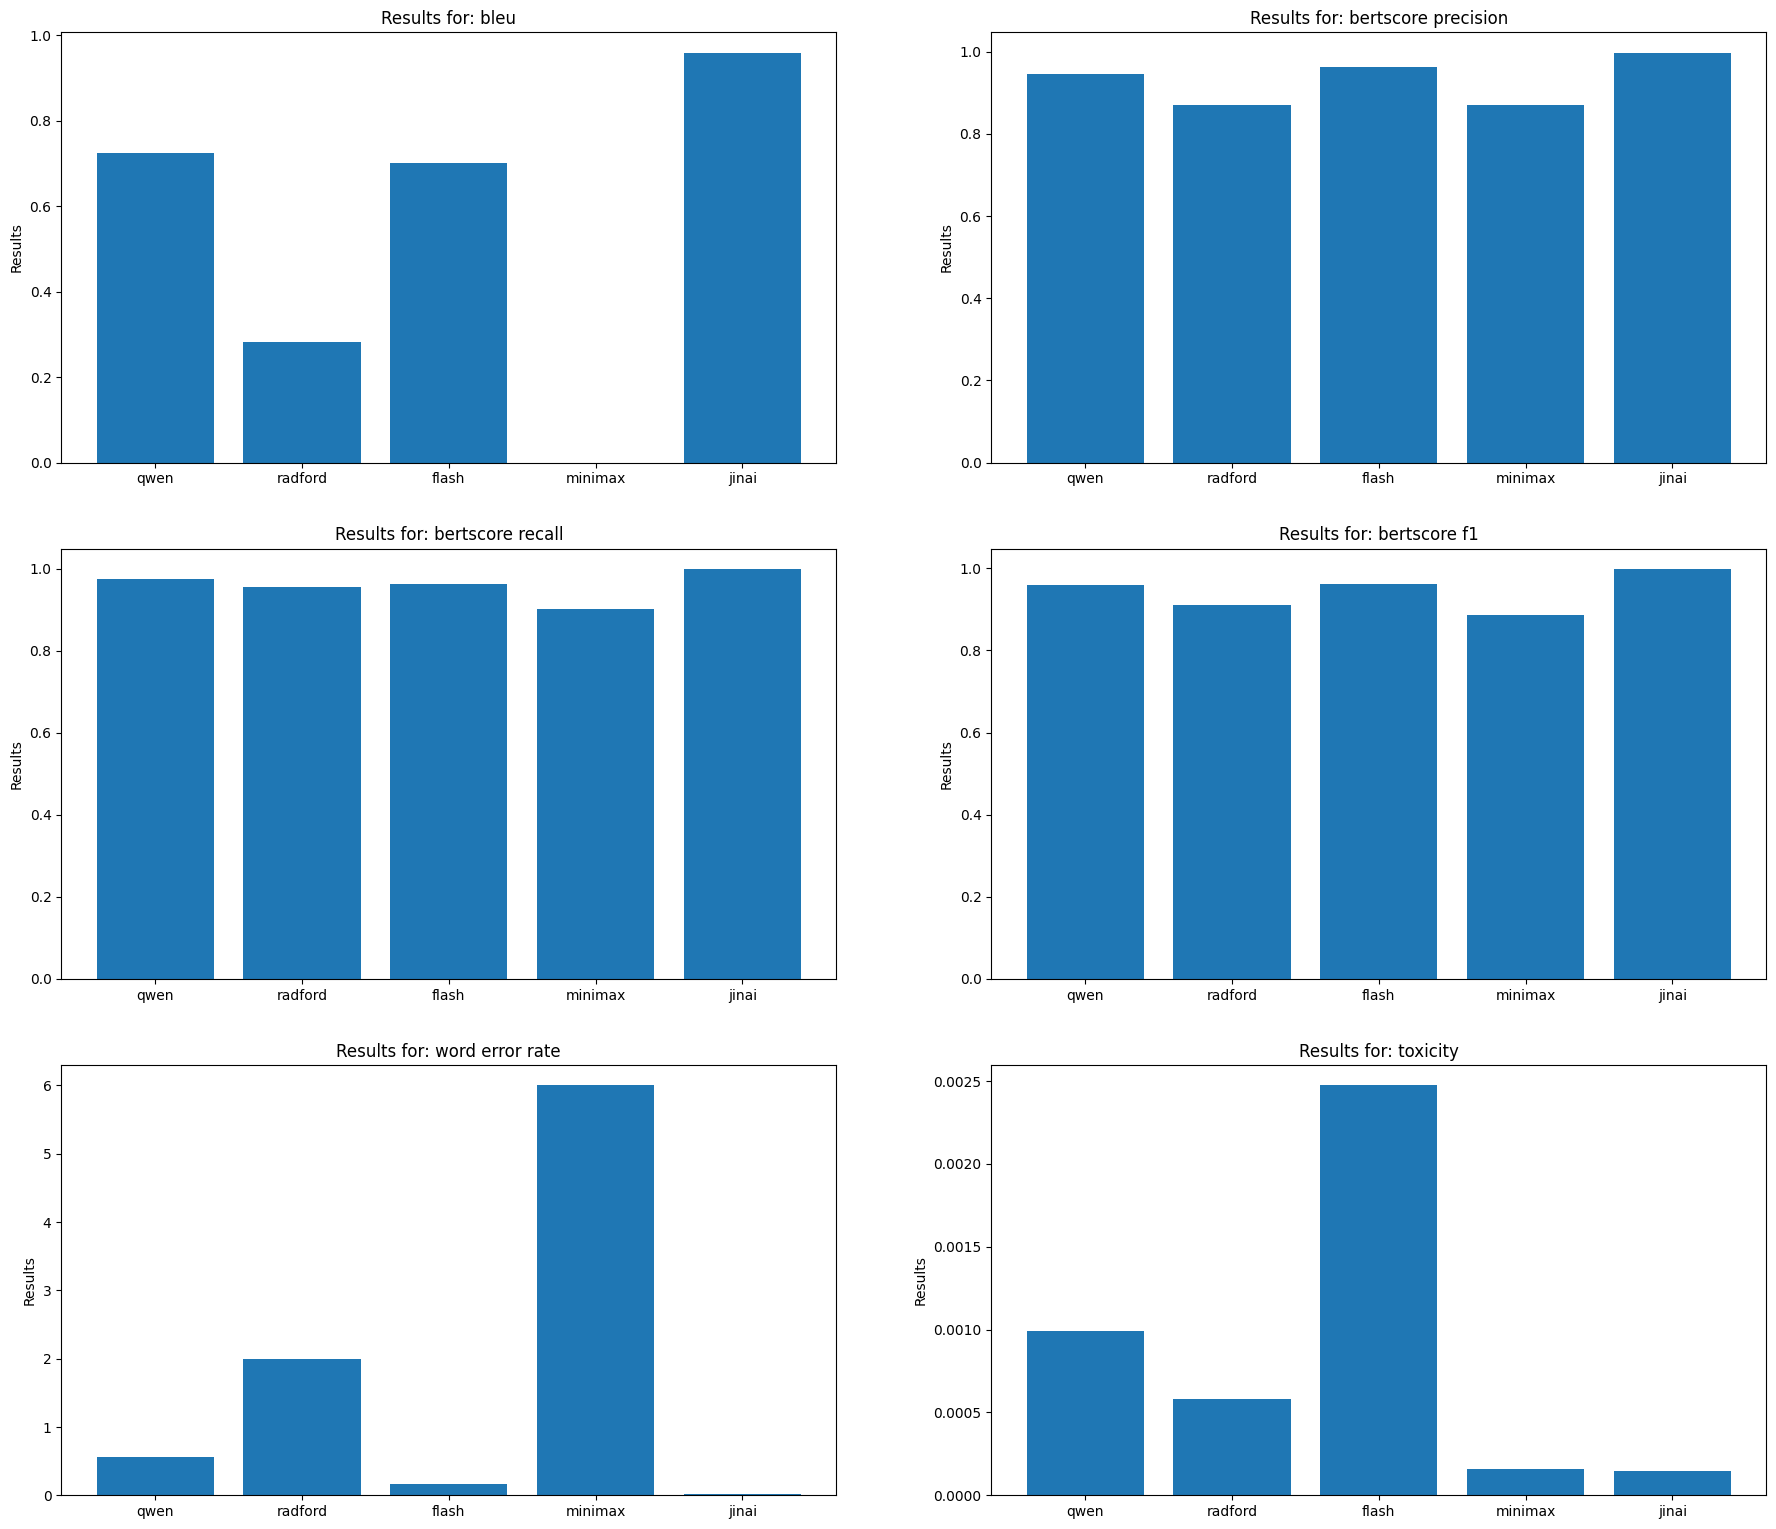

In [ ]:
import matplotlib.pyplot as plt

results = {
    'qwen': [qwen_bleu_results, qwen_bertscore_results_precision, qwen_bertscore_results_recall, qwen_bertscore_results_f1, wer_qwen, toxicity_qwen_results['toxicity'][0]],
    'radford': [radford_bleu_results_gpt2, radford_bertscore_results_gpt2_precision, radford_bertscore_results_gpt2_recall, radford_bertscore_results_gpt2_f1, wer_gpt2, toxicity_gpt2_results['toxicity'][0]],
    'flash': [flash_bleu_results_completion, flash_bertscore_results_completion_precision, flash_bertscore_results_completion_recall, flash_bertscore_results_completion_f1, flash_wer_results_completion, flash_toxicity_results_completion['toxicity'][0]],
    'minimax': [minimax_bleu_results_completion, minimax_bertscore_results_completion_precision, minimax_bertscore_results_completion_recall, minimax_bertscore_results_completion_f1, minimax_wer_results_completion, minimax_toxicity_results_completion['toxicity'][0]],
    'jinai': [bleu_results_completion, bertscore_results_completion_precision, bertscore_results_completion_recall, bertscore_results_completion_f1, wer_results_completion, toxicity_results_completion['toxicity'][0]]
}

metrics = ['bleu', 'bertscore precision', 'bertscore recall', 'bertscore f1', 'word error rate', 'toxicity']

num_plots = 6

fig, axes = plt.subplots(num_plots//2, 2, figsize=(6*2 + 10, 3*num_plots//2 + 10))
axes = axes.flatten()

for i in range(num_plots):
  values = [results[k][i] for k in results.keys()]
  axes[i].bar(results.keys(), values)
  axes[i].set_title(f'Results for: {metrics[i]}')
  axes[i].set_ylabel('Results')

Selected model is jinai due to its high bleu and bertscore scores and low word error rate and toxicity.